# Punkty Charakterystyczne 

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy . ndimage . filters as filters
from scipy.ndimage import maximum_filter

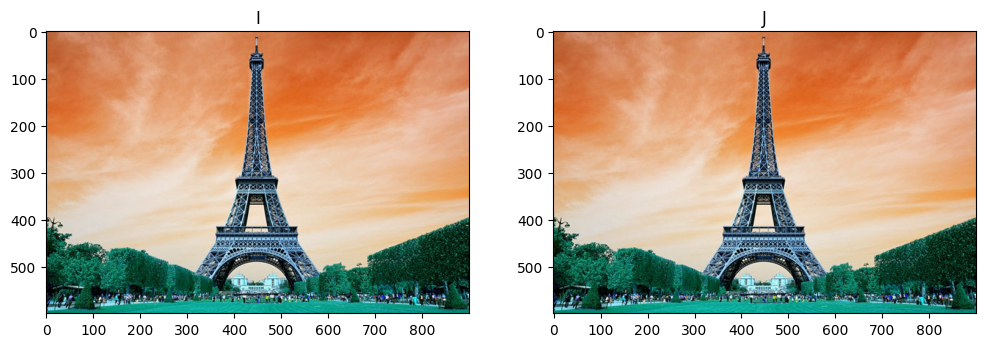

In [48]:
# I_path = 'fontanna1.jpg'
# J_path = 'fontanna2.jpg'

I_path = 'eiffel1.jpg'
J_path = 'eiffel1.jpg'

I = cv2.imread(I_path)
J = cv2.imread(J_path)


fig, axs = plt.subplots(1, 2, figsize=(12, 10))

axs[0].set_title("I")
axs[0].imshow(I)

axs[1].set_title("J")
axs[1].imshow(J)

In [49]:
class FP_Harris():
    def __init__(self):
        pass

    def Harris(self, gray: np.ndarray, sobel_size: int, gauss_size: int) -> np.ndarray:
        if not isinstance(gray, np.ndarray):
            print("Input is not a valid numpy array")
            return None

        if len(gray.shape) != 2:
            print("Input must be a grayscale image")
            return None

        # Parametr K
        k = 0.05

        # Pochodne po x i y
        Ix = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=sobel_size)
        Iy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=sobel_size)

        # Wyliczenie składników macierzy autokorelacji
        Ixx = cv2.GaussianBlur(Ix * Ix, (gauss_size, gauss_size), 0)
        Ixy = cv2.GaussianBlur(Ix * Iy, (gauss_size, gauss_size), 0)
        Iyy = cv2.GaussianBlur(Iy * Iy, (gauss_size, gauss_size), 0)

        # Wyznacznik i ślad
        detM = Ixx * Iyy - Ixy * Ixy
        traceM = Ixx + Iyy

        # Obliczenie odpowiedzi Harris'a
        H = detM - k * (traceM ** 2)

        # Normalizacja do zakresu [0, 1]
        H_norm = cv2.normalize(H, None, 0, 1, cv2.NORM_MINMAX)

        return H_norm

    def find_max(self, image, size, threshold):  # size - maximum filter mask size
        data_max = maximum_filter(image, size)
        maxima = image == data_max
        diff = image > threshold
        maxima[diff == 0] = 0
        return np.nonzero(maxima)
    
    def plot_Harris(self, image, points):
        fig, axs = plt.subplots(1, 1, figsize=(12, 10))

        axs.set_title("I")
        axs.imshow(image)
        axs.plot(points[1], points[0], '*', color='r')

    def describe_points(self, image: np.ndarray, points: tuple, size: int) -> list:
        Y, X = image.shape

        # Filtrowanie punktów – tylko te, które mają pełne otoczenie
        filtered_pts = list(filter(
            lambda pt: pt[0] >= size and pt[0] < Y - size and pt[1] >= size and pt[1] < X - size,
            zip(points[0], points[1])
        ))

        list_patches = []
        l_fp_coords = []

        for y, x in filtered_pts:
            patch = image[y - size:y + size + 1, x - size:x + size + 1]
            vec = patch.flatten()
            list_patches.append(vec)
            l_fp_coords.append((y, x))

        # Połączenie opisów z ich współrzędnymi
        wynik_funkcji = list(zip(list_patches, l_fp_coords))

        return wynik_funkcji
    
    def describe_points2(self, image: np.ndarray, points: tuple, size: int) -> list:
        Y, X = image.shape

        # Filtrowanie punktów – tylko te, które mają pełne otoczenie
        filtered_pts = list(filter(
            lambda pt: pt[0] >= size and pt[0] < Y - size and pt[1] >= size and pt[1] < X - size,
            zip(points[0], points[1])
        ))

        list_patches = []
        l_fp_coords = []

        for y, x in filtered_pts:
            patch = image[y - size:y + size + 1, x - size:x + size + 1]
            vec = patch.flatten().astype(np.float32)

            mean = np.mean(vec)
            std = np.std(vec)

            # Afiniczna normalizacja: (vec - mean) / std
            if std > 1e-5:
                vec_norm = (vec - mean) / std
            else:
                vec_norm = vec - mean  # Jeśli std bliskie zeru, nie dzielimy

            list_patches.append(vec_norm)
            l_fp_coords.append((y, x))

        wynik_funkcji = list(zip(list_patches, l_fp_coords))

        return wynik_funkcji

    def match_descriptors(self, desc1: list, desc2: list, n: int) -> list:
        matches = []

        for vec1, coord1 in desc1:
            best_match = None
            best_score = float('inf')

            for vec2, coord2 in desc2:
                # Możemy wybrać różne metryki – tutaj: suma wartości bezwzględnych różnic (L1)
                L1 = lambda vec1, vec2: np.sum(np.abs(vec1 - vec2))
                score = L1(vec1, vec2)

                if score < best_score:
                    best_score = score
                    best_match = (coord1, coord2, score)

            matches.append(best_match)

        # Sortujemy wszystkie dopasowania według podobieństwa (score)
        matches.sort(key=lambda x: x[2])  # x[2] to wartość miary podobieństwa

        # Zwracamy `n` najlepszych dopasowań
        return matches[:n]
    
    def plot_matches(self, img1, img2, matches):
        h1, w1 = img1.shape[:2]
        h2, w2 = img2.shape[:2]

        # Jeśli obrazy są jednokanałowe, konwertujemy je do 3 kanałów (RGB)
        if len(img1.shape) == 2:
            img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
        if len(img2.shape) == 2:
            img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

        # Tworzymy nowy obraz do wyświetlenia obu obrazów obok siebie
        new_img = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
        new_img[:h1, :w1] = img1
        new_img[:h2, w1:w1 + w2] = img2

        plt.figure(figsize=(12, 10))
        plt.imshow(new_img)

        for idx, ((y1, x1), (y2, x2), _) in enumerate(matches):
            plt.plot([x1, x2 + w1], [y1, y2], 'r-', linewidth=1)
            plt.plot(x1, y1, 'go')
            plt.plot(x2 + w1, y2, 'bo')
            plt.text(x1 + 2, y1, str(idx), color='lime', fontsize=8)
            plt.text(x2 + w1 + 2, y2, str(idx), color='cyan', fontsize=8)

        plt.title('Najlepsze dopasowania z numerami punktów')
        plt.axis('off')
        plt.show()



fp_harris = FP_Harris()

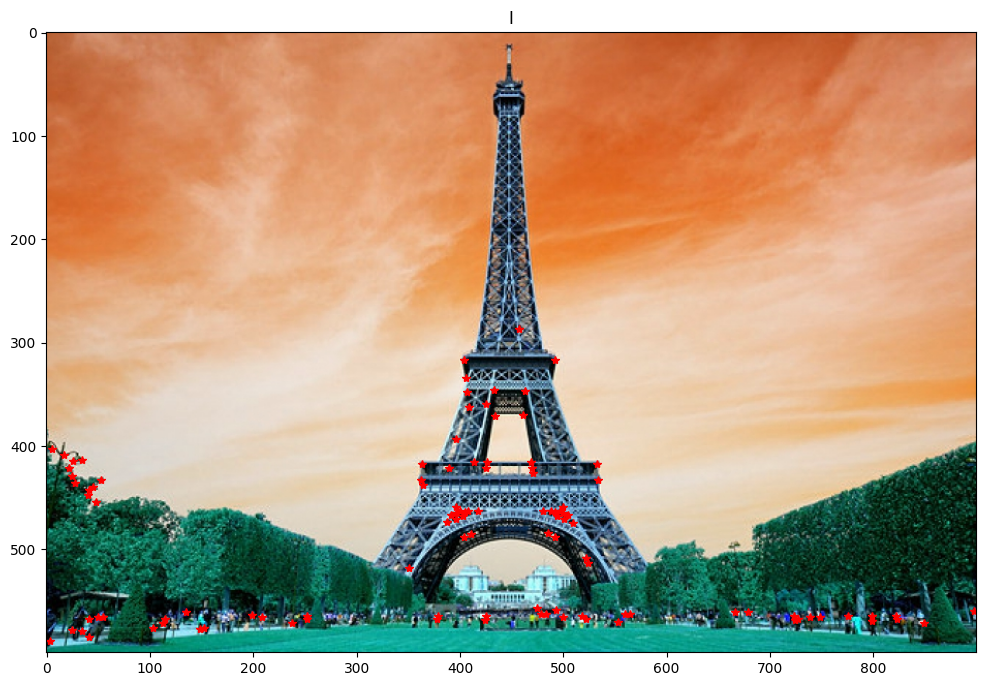

In [50]:
H_norm = fp_harris.Harris(cv2.cvtColor(I, cv2.COLOR_RGB2GRAY), 7, 7)

points = fp_harris.find_max(H_norm, 5, 0.4)

fp_harris.plot_Harris(I, points)

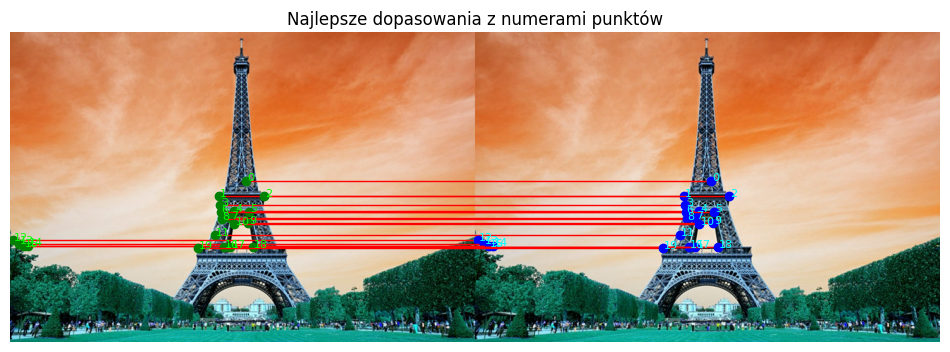

In [51]:

# Harris corner detection
H1 = fp_harris.Harris(cv2.cvtColor(I, cv2.COLOR_RGB2GRAY), sobel_size=7, gauss_size=7)
H2 = fp_harris.Harris(cv2.cvtColor(J, cv2.COLOR_RGB2GRAY), sobel_size=7, gauss_size=7)

# Znalezienie punktów maksymalnych
pts1 = fp_harris.find_max(H1, size=5, threshold=0.4)
pts2 = fp_harris.find_max(H2, size=5, threshold=0.4)

# Tworzenie deskryptorów
desc1 = fp_harris.describe_points2(H1, pts1, size=3)
desc2 = fp_harris.describe_points2(H2, pts2, size=3)

# Dopasowanie deskryptorów
matches = fp_harris.match_descriptors(desc1, desc2, n=20)

fp_harris.plot_matches(I, J, matches)


## ORB (FAST+BRIEF)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class FASTDetector:
    def __init__(self, radius=3, num_points=16, threshold=20, min_consecutive=12):
        # Parametry detektora FAST
        self.radius = radius
        self.num_points = num_points
        self.threshold = threshold
        self.min_consecutive = min_consecutive
        self.circle_offsets = self.get_circle_offsets()

    def get_circle_offsets(self):
        # Generowanie przesunięć punktów na okręgu
        angles = np.linspace(0, 2 * np.pi, self.num_points, endpoint=False)
        return [(int(round(self.radius * np.cos(a))),
                 int(round(self.radius * np.sin(a)))) for a in angles]

    def has_n_consecutive_true(self, lst, n):
        # Sprawdzanie, czy są n kolejnych prawd w liście
        lst = lst + lst[:n-1]  # wrap-around
        count = 0
        for val in lst:
            count = count + 1 if val else 0
            if count >= n:
                return True
        return False

    def is_corner(self, img, x, y):
        # Sprawdzanie, czy dany piksel jest punktem charakterystycznym
        center = img[y, x]
        try:
            values = [img[y + dy, x + dx] for dx, dy in self.circle_offsets]
        except IndexError:
            return False

        brighter = [v > center + self.threshold for v in values]
        darker = [v < center - self.threshold for v in values]

        return (self.has_n_consecutive_true(brighter, self.min_consecutive) or
                self.has_n_consecutive_true(darker, self.min_consecutive))

    def detect(self, img):
        # Detekcja punktów FAST na obrazie
        keypoints = []
        h, w = img.shape[:2]
        margin = self.radius
        for y in range(margin, h - margin):
            for x in range(margin, w - margin):
                if self.is_corner(img, x, y):
                    keypoints.append((x, y))
        return keypoints

    def compute_harris_response(self, img, keypoints):
        # Obliczanie miary Harrisa dla punktów charakterystycznych
        harris = cv2.cornerHarris(np.float32(img), blockSize=2, ksize=3, k=0.04)
        return [harris[y, x] for x, y in keypoints]

    def draw_keypoints(self, img, keypoints, color=(0, 255, 0)):
        # Rysowanie wykrytych punktów na obrazie
        img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        for (x, y) in keypoints:
            cv2.circle(img_color, (x, y), 2, color, 1)
        return img_color

    def non_maximum_suppression(self, keypoints, window_size=3):
        # Non-Maximum Suppression - usuwanie punktów, które są zbyt blisko siebie
        suppressed = []
        keypoints = sorted(keypoints, key=lambda kp: kp[2], reverse=True)
        for i, (x, y, score) in enumerate(keypoints):
            # Sprawdzanie otoczenia 3x3
            is_suppressed = False
            for j, (sx, sy, _) in enumerate(suppressed):
                if abs(sx - x) <= window_size and abs(sy - y) <= window_size:
                    is_suppressed = True
                    break
            if not is_suppressed:
                suppressed.append((x, y, score))
        return suppressed

    def compute_centroid(self, keypoints):
        # Wyznaczenie centroidu dla punktów
        x_coords = [kp[0] for kp in keypoints]
        y_coords = [kp[1] for kp in keypoints]
        return np.mean(x_coords), np.mean(y_coords)

    def compute_orientation(self, keypoints, centroid):
        # Wyznaczenie orientacji na podstawie centroidu
        cx, cy = centroid
        angles = []
        for (x, y, _) in keypoints:
            angle = np.arctan2(y - cy, x - cx)
            angles.append(angle)
        return np.mean(angles)

    def compute_brief_descriptor(self, img, keypoints, size=31):
        # Generowanie deskryptorów BRIEF
        descriptors = []
        half_size = size // 2
        for (x, y) in keypoints:
            # Wycinamy fragment obrazu o rozmiarze 31x31
            patch = img[y-half_size:y+half_size+1, x-half_size:x+half_size+1]
            if patch.shape[0] != size or patch.shape[1] != size:
                continue

            # Rozmycie Gaussa (5x5) przed użyciem BRIEF
            patch = cv2.GaussianBlur(patch, (5, 5), 0)

            # Generowanie losowych par punktów
            random_pairs = np.random.randint(0, size*size, (256, 2))
            brief = np.zeros(256, dtype=np.uint8)

            # Wykonanie testu binarnego na parach punktów
            for i, (p1, p2) in enumerate(random_pairs):
                y1, x1 = divmod(p1, size)
                y2, x2 = divmod(p2, size)

                if patch[y1, x1] > patch[y2, x2]:
                    brief[i] = 1

            descriptors.append(brief)

        return descriptors

    def hamming_distance(self, desc1, desc2):
        # Wyznaczanie odległości Hamminga pomiędzy dwoma deskryptorami BRIEF
        return np.count_nonzero(desc1 != desc2)

    def match_descriptors(self, descriptors1, descriptors2, threshold=50):
        # Porównanie deskryptorów między dwoma obrazami
        matches = []
        for i, d1 in enumerate(descriptors1):
            best_match = None
            best_distance = float('inf')
            for j, d2 in enumerate(descriptors2):
                distance = self.hamming_distance(d1, d2)
                if distance < best_distance:
                    best_distance = distance
                    best_match = j
            if best_distance < threshold:
                matches.append((i, best_match, best_distance))
        return matches

    def detect_and_match_keypoints(self, img1, img2):
        # Detekcja punktów charakterystycznych
        keypoints1 = self.detect(img1)
        keypoints2 = self.detect(img2)

        # Obliczenie miary Harrisa dla punktów
        harris_vals1 = self.compute_harris_response(img1, keypoints1)
        harris_vals2 = self.compute_harris_response(img2, keypoints2)

        # Non-maximum suppression
        keypoints1_suppressed = self.non_maximum_suppression([(x, y, score) for (x, y), score in zip(keypoints1, harris_vals1)])
        keypoints2_suppressed = self.non_maximum_suppression([(x, y, score) for (x, y), score in zip(keypoints2, harris_vals2)])

        # Generowanie deskryptorów BRIEF
        descriptors1 = self.compute_brief_descriptor(img1, [kp[:2] for kp in keypoints1_suppressed])
        descriptors2 = self.compute_brief_descriptor(img2, [kp[:2] for kp in keypoints2_suppressed])

        # Dopasowanie deskryptorów
        matches = self.match_descriptors(descriptors1, descriptors2)

        # Wizualizacja wyników
        img1_out = self.draw_keypoints(img1, keypoints1)
        img2_out = self.draw_keypoints(img2, keypoints2)

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.title('Fontanna 1 - Detekcja FAST')
        plt.imshow(img1_out)

        plt.subplot(1, 2, 2)
        plt.title('Fontanna 2 - Detekcja FAST')
        plt.imshow(img2_out)

        plt.show()

fast_det = FASTDetector(radius=7, threshold=30)

# Wczytanie obrazów
img1 = cv2.imread('fontanna1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('fontanna2.jpg', cv2.IMREAD_GRAYSCALE)

# Wywołanie funkcji detekcji i dopasowania punktów
fast_det.detect_and_match_keypoints(img1, img2)


/tmp/ipykernel_8531/508303452.py:38: RuntimeWarning: overflow encountered in scalar add
  brighter = [v > center + self.threshold for v in values]
/tmp/ipykernel_8531/508303452.py:39: RuntimeWarning: overflow encountered in scalar subtract
  darker = [v < center - self.threshold for v in values]


KeyboardInterrupt: 

## Wykorzystanie punktów charakterystycznych do ł ˛aczenia obrazów